# TCRpred

#### A.S. Smirnov, A.V. Rudik, D.A. Filimonov, A.A. Lagunin

Purpose of the TCRpred is predicts some features about pathogen recognition by T cells. The models use third complementarity-determining region(CDR3) sequences of T cell receptors(TCR) or peptide epitopes sequences. TCRpred based on Prediction of Activity Spectra for Substances(PASS)[1]. PASS uses naive Bayes classifier and Multilevel Neighbourhoods of Atoms(MNA) descriptors.

<table>
<caption>Table 1. Types of models</caption>
<tr><th>Predictor</th><th>Predictable feature</th></tr>
<tr><td>CDR3 seq</td><td>Epitope seq, TCR host species, TCR chain</td></tr>
<tr><td>CDR3 seq</td><td>MHC class and allele of a alpha chain,chain of a TCR</td></tr>
<tr><td>Epitope</td><td>MHC class and allele of a alpha chain,chain of a TCR</td></tr>
</table>

The data has compilated from three sources: Immune Epitode Database[2], VDJdb[3], McPAS-TCR[4].

<ol>
<li>Filimonov D.A., Lagunin A.A., Gloriozova T.A., Rudik A.V., Druzhilovskii D.S., Pogodin P.V., Poroikov V.V. (2014). Prediction of the biological activity spectra of organic compounds using the PASS online web resource. Chemistry of Heterocyclic Compounds, 50 (3), 444-457.</li>
<li>Vita R, Mahajan S, Overton JA, Dhanda SK, Martini S, Cantrell JR, Wheeler DK, Sette A, Peters B. The Immune Epitope Database (IEDB): 2018 update. Nucleic Acids Res. 2018 Oct 24. doi: 10.1093/nar/gky1006. [Epub ahead of print] PubMed PMID: 30357391.</li>
<li>Dmitry V Bagaev, Renske M A Vroomans, Jerome Samir, Ulrik Stervbo, Cristina Rius, Garry Dolton, Alexander Greenshields-Watson, Meriem Attaf, Evgeny S Egorov, Ivan V Zvyagin, Nina Babel, David K Cole, Andrew J Godkin, Andrew K Sewell, Can Kesmir, Dmitriy M Chudakov, Fabio Luciani, Mikhail Shugay, VDJdb in 2019: database extension, new analysis infrastructure and a T-cell receptor motif compendium, Nucleic Acids Research, gkz874. doi:10.1093/nar/gkz874.</li>
<li>Tickotsky N, Sagiv T, Prilusky J, Shifrut E, Friedman N (2017). McPAS-TCR: A manually-curated catalogue of pathology-associated T cell receptor sequences. Bioinformatics 33:2924-2929</li>
</ol>

## Data extraction

### Immune Epitope Database

The database downloaded from the official site - iedb.org. It deployed on MySQL server v.8.0.27-0. CDR3, epitopes sequences, VDJ, MHC alleles, MHC class, TCR chain, host species and presence of a response were extracted from IEDB by next query.

<code>
use iedb;

create view CDR3 as select tcell.tcell_id, as_char_value, chain_type, cdr3_seq,v_gene,d_gene,j_gene from tcell
inner join tcell_receptor on tcell.tcell_id = tcell_receptor.tcell_id
inner join curated_receptor on tcell_receptor.curated_receptor_id = curated_receptor.curated_receptor_id
inner join chain on (curated_receptor.chain1_id_cur = chain_id or curated_receptor.chain2_id_cur = chain_id)
where (chain_type = 'alpha' or chain_type = 'beta') and not isnull(cdr3_seq);

create view ORGANISMSAMPLE as select tcell.tcell_id, h_organism_id,name_txt,name_class from tcell
inner join organism on organism.organism_id = h_organism_id
inner join organism_names on organism.organism_id = organism_names.organism_id
where name_class = 'scientific name';

create view MHC as select tcell.tcell_id, class, chain_i_name, chain_ii_name from tcell
inner join mhc_allele_restriction on tcell.mhc_allele_restriction_id = mhc_allele_restriction.mhc_allele_restriction_id;

create view EPITOPESAB as select tcell.tcell_id, linear_peptide_seq,linear_peptide_modification from tcell
inner join curated_epitope on tcell.curated_epitope_id = curated_epitope.curated_epitope_id
inner join epitope_object on epitope_object.object_id = curated_epitope.e_object_id
inner join epitope on epitope_object.epitope_id = epitope.epitope_id
where isnull(linear_peptide_modification) and not isnull(linear_peptide_seq);

select CDR3.tcell_id, as_char_value, chain_type, cdr3_seq,v_gene,d_gene,j_gene,name_txt,class, chain_i_name, chain_ii_name,linear_peptide_seq
        from CDR3
inner join ORGANISMSAMPLE on CDR3.tcell_id = ORGANISMSAMPLE.tcell_id
inner join MHC on CDR3.tcell_id = MHC.tcell_id
inner join EPITOPESAB on CDR3.tcell_id = EPITOPESAB.tcell_id;
</code>

For optimization purposes intermediate selections was saved. The final result was saved in Excel.

### VDJdb and McPAS-TCR

The databases downloaded from the official sites in csv format. VDJdb database separator is '\t'. McPAS-TCR database separator is colon.

## Data preparation

The data from databases collected into 1 excel file. Data mapping to IEDB.

### Import

In [1]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

### Data mapping

In [11]:
#Map species info to iedb data. Too long execute

#iedb = pd.read_excel("~/DataspellProjects/epitops/iedb.xlsx")
#epi = pd.read_excel("/home/stotoshka/DataspellProjects/epitops/info_epitopes.xlsx")
#iter = 0
#total = len(epi.index)
#for i in epi.index:
#    k = len(iedb[iedb['linear_peptide_seq'] == epi.loc[i,'linear_peptide_seq']].index)
#     if k > 0:
#        iedb.loc[iedb['linear_peptide_seq'] == epi.loc[i,'linear_peptide_seq'],'accession'] = epi.loc[i,'accession']
#        iedb.loc[iedb['linear_peptide_seq'] == epi.loc[i,'linear_peptide_seq'],'database_access'] = epi.loc[i,'database_access']
#        iedb.loc[iedb['linear_peptide_seq'] == epi.loc[i,'linear_peptide_seq'],'protein_name'] = epi.loc[i,'protein_name']
#        iedb.loc[iedb['linear_peptide_seq'] == epi.loc[i,'linear_peptide_seq'],'source_species'] = epi.loc[i,'source_species']
#    iter += 1
#    printProgressBar(iter,total)
#iedb.head()

In [2]:
iedb = pd.read_excel("~/DataspellProjects/epitops/iedb_with_sp.xlsx")
iedb.head()

,tcell_id,as_char_value,chain_type,cdr3_seq,v_gene,d_gene,j_gene,name_txt,class,chain_i_name,chain_ii_name,linear_peptide_seq,accession,database_access,protein_name,source_species
0,1031722,Positive,beta,ASSRGQGEQY,TCRBV14,NaN,TCRBJ2-7,Homo sapiens,I,HLA-B*08:01,Beta-2-microglobulin,RAKFKQLL,P03206.2,GenPept,Trans-activator protein BZLF1,Human herpesvirus 4 strain B95-8 (Epstein-Barr...
1,1031722,Positive,beta,ASSFSRNTGEL,TCRBV14,NaN,TCRBJ2-2,Homo sapiens,I,HLA-B*08:01,Beta-2-microglobulin,RAKFKQLL,P03206.2,GenPept,Trans-activator protein BZLF1,Human herpesvirus 4 strain B95-8 (Epstein-Barr...
2,1031720,Positive,beta,ASSRSPGGTQY,TCRBV14,NaN,TCRBJ2-5,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus)
3,1031720,Positive,beta,ASGQSPGGTQY,TCRBV14,NaN,TCRBJ2-5,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus)
4,1031720,Positive,beta,ASDSGVGNTIY,TCRBV2,NaN,TCRBJ1-3,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus)


In [3]:
mcpas = pd.read_csv("/home/stotoshka/DataspellProjects/epitops/McPAS-TCR.csv",sep = ',', encoding='windows-1252')
mcpas.head()

/usr/local/lib/python3.8/dist-packages/IPython/core/interactiveshell.py:3457: DtypeWarning: Columns (13,17,24,26,28) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
0,NaN,CASSDAGANTEVF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,No,...,NaN,NaN,TRBV8-1,NaN,TRBJ1-1,No,NaN,P14,1716213,NaN
1,NaN,CASSDAGAYAEQF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,No,...,NaN,NaN,TRBV8-1,NaN,TRBJ2-1,No,NaN,P14,1716213,NaN
2,NaN,CASSDAGGAAEVF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,No,...,NaN,NaN,TRBV8-3,NaN,TRBJ1-1,No,NaN,P14,1716213,NaN
3,NaN,CASSDAGHSPLYF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,No,...,NaN,NaN,TRBV8-1,NaN,TRBJ1-6,No,NaN,P14,1716213,NaN
4,NaN,CASSDAWGGAEQYF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,No,...,NaN,NaN,TRBV8-3,NaN,TRBJ2-6,No,NaN,P14,1716213,NaN


In [4]:
vdjdb = pd.read_csv("/home/stotoshka/DataspellProjects/epitops/vdjdb.tsv",sep="\t")
vdjdb = vdjdb[vdjdb["CDR3fix"].str.contains("\"good\": true")]
vdjdb.loc[vdjdb["MHC A"] == "H-2KB","MHC A"] = "H-2Kb"
vdjdb.head()

,complex.id,Gene,CDR3,V,J,Species,MHC A,MHC B,MHC class,Epitope,Epitope gene,Epitope species,Reference,Method,Meta,CDR3fix,Score
0,1,TRA,CIVRAPGRADMRF,TRAV26-1*01,TRAJ43*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,"{""frequency"": """", ""identification"": ""tetramer-...","{""cell.subset"": ""CD8+"", ""clone.id"": """", ""donor...","{""cdr3"": ""CIVRAPGRADMRF"", ""cdr3_old"": ""CIVRAPG...",2
1,1,TRB,CASSYLPGQGDHYSNQPQHF,TRBV13*01,TRBJ1-5*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,"{""frequency"": """", ""identification"": ""tetramer-...","{""cell.subset"": ""CD8+"", ""clone.id"": """", ""donor...","{""cdr3"": ""CASSYLPGQGDHYSNQPQHF"", ""cdr3_old"": ""...",2
2,0,TRB,CASSFEAGQGFFSNQPQHF,TRBV13*01,TRBJ1-5*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,"{""frequency"": """", ""identification"": ""tetramer-...","{""cell.subset"": ""CD8+"", ""clone.id"": """", ""donor...","{""cdr3"": ""CASSFEAGQGFFSNQPQHF"", ""cdr3_old"": ""C...",2
3,2,TRA,CAVPSGAGSYQLTF,TRAV20*01,TRAJ28*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,"{""frequency"": """", ""identification"": ""tetramer-...","{""cell.subset"": ""CD8+"", ""clone.id"": """", ""donor...","{""cdr3"": ""CAVPSGAGSYQLTF"", ""cdr3_old"": ""CAVPSG...",2
4,2,TRB,CASSFEPGQGFYSNQPQHF,TRBV13*01,TRBJ1-5*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,"{""frequency"": """", ""identification"": ""tetramer-...","{""cell.subset"": ""CD8+"", ""clone.id"": """", ""donor...","{""cdr3"": ""CASSFEPGQGFYSNQPQHF"", ""cdr3_old"": ""C...",2


In [5]:
# Print iterations progress
def printProgressBar (iteration, total, prefix = '', suffix = '', decimals = 1, length = 100, fill = '█', printEnd = "\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end = printEnd)
    # Print New Line on Complete
    if iteration == total:
        print()

In [6]:
all = iedb.copy()
all.drop("tcell_id", axis = 1, inplace= True)
all["Source"] = "IEDB"
all.head()

,as_char_value,chain_type,cdr3_seq,v_gene,d_gene,j_gene,name_txt,class,chain_i_name,chain_ii_name,linear_peptide_seq,accession,database_access,protein_name,source_species,Source
0,Positive,beta,ASSRGQGEQY,TCRBV14,NaN,TCRBJ2-7,Homo sapiens,I,HLA-B*08:01,Beta-2-microglobulin,RAKFKQLL,P03206.2,GenPept,Trans-activator protein BZLF1,Human herpesvirus 4 strain B95-8 (Epstein-Barr...,IEDB
1,Positive,beta,ASSFSRNTGEL,TCRBV14,NaN,TCRBJ2-2,Homo sapiens,I,HLA-B*08:01,Beta-2-microglobulin,RAKFKQLL,P03206.2,GenPept,Trans-activator protein BZLF1,Human herpesvirus 4 strain B95-8 (Epstein-Barr...,IEDB
2,Positive,beta,ASSRSPGGTQY,TCRBV14,NaN,TCRBJ2-5,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus),IEDB
3,Positive,beta,ASGQSPGGTQY,TCRBV14,NaN,TCRBJ2-5,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus),IEDB
4,Positive,beta,ASDSGVGNTIY,TCRBV2,NaN,TCRBJ1-3,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus),IEDB


#### VDJdb mapping

In [7]:
total = len(vdjdb.index)
k = 0
iter = 0
printProgressBar(0, total, prefix = 'Progress:', suffix = 'Complete', length = 50)
p_vdjdb = pd.DataFrame(columns=all.columns)
for i in vdjdb.index:
    chain = None
    if vdjdb.loc[i,"Gene"] == 'TRA':
        chain = 'alpha'
    elif vdjdb.loc[i,"Gene"] == 'TRB':
        chain = 'beta'
    p_vdjdb.loc[k] = ('Positive',chain,vdjdb.loc[i,'CDR3'],vdjdb.loc[i,'V'],None,vdjdb.loc[i,'J'],vdjdb.loc[i,'Species'],vdjdb.loc[i,'MHC class'],vdjdb.loc[i,'MHC A'],vdjdb.loc[i,'MHC B'],vdjdb.loc[i,'Epitope'],'','',vdjdb.loc[i,'Epitope gene'],vdjdb.loc[i,'Epitope species'],"VDJdb")
    k += 1
    iter += 1
    printProgressBar(iter, total, prefix = 'Progress:', suffix = 'Complete', length = 50)
all = all.append(p_vdjdb,ignore_index = True)
print(len(all.index))

Progress: |██████████████████████████████████████████████████| 100.0% Complete
319674


#### McPAS-TCR mapping

In [8]:
#long, need optimize
total = len(mcpas.index)
k = 0
printProgressBar(0, total, prefix = 'Progress:', suffix = 'Complete', length = 50)
p_mcpas = pd.DataFrame(columns=all.columns)
iter = 0
for i in mcpas.index:
    chain = None
    cdr3 = None
    if pd.isna(mcpas.loc[i,'CDR3.alpha.aa']):
        chain = 'beta'
        cdr3 = mcpas.loc[i,'CDR3.beta.aa']
        v = mcpas.loc[i,'TRBV']
        d = mcpas.loc[i,'TRBD']
        j = mcpas.loc[i,'TRBJ']
        p_mcpas.loc[k] = ('Positive',chain,cdr3,v,d,j,mcpas.loc[i,'Species'],None,mcpas.loc[i,'MHC'],None,mcpas.loc[i,'Epitope.peptide'],
                          '','',mcpas.loc[i,'Antigen.protein'],mcpas.loc[i,'Pathology'],"McPAS-TCR")
        k += 1
    elif pd.isna(mcpas.loc[i,'CDR3.beta.aa']):
        chain = 'alpha'
        cdr3 = mcpas.loc[i,'CDR3.alpha.aa']
        v = mcpas.loc[i,'TRAV']
        d = None
        j = mcpas.loc[i,'TRAJ']
        p_mcpas.loc[k] = ('Positive',chain,cdr3,v,d,j,mcpas.loc[i,'Species'],None,mcpas.loc[i,'MHC'],None,mcpas.loc[i,'Epitope.peptide'],
                          mcpas.loc[i,'Epitope.peptide'],"McPAS-TCR",mcpas.loc[i,'Antigen.protein'],mcpas.loc[i,'Pathology'],"McPAS-TCR")
        k+=1
    else:
        p_mcpas.loc[k] = ('Positive','alpha',mcpas.loc[i,'CDR3.alpha.aa'],v,d,j,mcpas.loc[i,'Species'],None,mcpas.loc[i,'MHC'],None,mcpas.loc[i,'Epitope.peptide'],mcpas.loc[i,'Epitope.peptide'],"McPAS-TCR",mcpas.loc[i,'Antigen.protein'],mcpas.loc[i,'Pathology'],"McPAS-TCR")
        k+=1
        p_mcpas.loc[k] = ('Positive','beta',mcpas.loc[i,'CDR3.beta.aa'],v,d,j,mcpas.loc[i,'Species'],None,mcpas.loc[i,'MHC'],None,mcpas.loc[i,'Epitope.peptide'],mcpas.loc[i,'Epitope.peptide'],"McPAS-TCR",mcpas.loc[i,'Antigen.protein'],mcpas.loc[i,'Pathology'],"McPAS-TCR")
        k+=1
    iter += 1
    printProgressBar(iter, total, prefix = 'Progress:', suffix = 'Complete', length = 50)
all = all.append(p_mcpas,ignore_index = True)
print(len(all.index))

Progress: |██████████████████████████████████████████████████| 100.0% Complete
371964


In [12]:
#save intermediate
all.rename(columns = {"name_txt":"host_species","linear_peptide_seq":"Epitope","chain_type":"TCR_chain"},inplace=True,copy = True)
all.to_excel("/home/stotoshka/DataspellProjects/epitops/all_not_processed.xlsx",index = False)

In [15]:
all.head()

,as_char_value,TCR_chain,cdr3_seq,v_gene,d_gene,j_gene,host_species,class,chain_i_name,chain_ii_name,Epitope,accession,database_access,protein_name,source_species,Source
0,Positive,beta,ASSRGQGEQY,TCRBV14,NaN,TCRBJ2-7,Homo sapiens,I,HLA-B*08:01,Beta-2-microglobulin,RAKFKQLL,P03206.2,GenPept,Trans-activator protein BZLF1,Human herpesvirus 4 strain B95-8 (Epstein-Barr...,IEDB
1,Positive,beta,ASSFSRNTGEL,TCRBV14,NaN,TCRBJ2-2,Homo sapiens,I,HLA-B*08:01,Beta-2-microglobulin,RAKFKQLL,P03206.2,GenPept,Trans-activator protein BZLF1,Human herpesvirus 4 strain B95-8 (Epstein-Barr...,IEDB
2,Positive,beta,ASSRSPGGTQY,TCRBV14,NaN,TCRBJ2-5,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus),IEDB
3,Positive,beta,ASGQSPGGTQY,TCRBV14,NaN,TCRBJ2-5,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus),IEDB
4,Positive,beta,ASDSGVGNTIY,TCRBV2,NaN,TCRBJ1-3,Homo sapiens,I,HLA-A*02:01,Beta-2-microglobulin,GLCTLVAML,CAD53409.1,GenPept,BMLF1 protein,Human herpesvirus 4 (Epstein Barr virus),IEDB


### Data cleaning

#### Drop rows without predictors

In [16]:
#import pandas as pd
#all = pd.read_excel("/home/stotoshka/DataspellProjects/epitops/all_not_processed.xlsx")
all = all[all['cdr3_seq'].notna() & all['Epitope'].notna() & all['host_species'].notna()]
len(all.index)

340898

#### Drop rows with non-canonical CDR3 sequences

Canonical CDR3 sequences starts with conserved cysteine and end with conserved phynilalanine or tryptophane.

In [17]:
def isCorrectSequence(seq):
    alphabet = list("ACDEFGHIKLMNPQRSTVWY")
    seq = seq.strip()
    for i in range(0,len(seq)):
        if seq[i] not in alphabet:
            return False
    return True

all["corrected_cdr3"] = all["cdr3_seq"].apply(isCorrectSequence)
all['conserved_cdr3'] = all['cdr3_seq'].apply(lambda x: x[0] == 'C' and (x[-1] == 'F' or x[-1] == 'W'))
all['good_cdr3'] = all["corrected_cdr3"] & all['conserved_cdr3']
all['good_epitope'] = all["Epitope"].apply(isCorrectSequence)

all = all[(all['good_cdr3'] == True) & (all['good_epitope'] == True)]
len(all.index)

/tmp/ipykernel_7683/1920770331.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all["corrected_cdr3"] = all["cdr3_seq"].apply(isCorrectSequence)
/tmp/ipykernel_7683/1920770331.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all['conserved_cdr3'] = all['cdr3_seq'].apply(lambda x: x[0] == 'C' and (x[-1] == 'F' or x[-1] == 'W'))
/tmp/ipykernel_7683/1920770331.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

296311

Remove conserved residues from CDR3 for remove non random noise.

In [18]:
all['cdr3_seq'] = all['cdr3_seq'].apply(lambda x: x[1:-1])

#### Clean Species, MHC class, Char_type

Species - Homo sapiens or Mus musculus. Drop rows with non classical MHC. Char_types are only positive or negative.

In [19]:
all.loc[all['class'] == 'MHCI','class'] = 'I'
all.loc[all['class'] == 'MHCII','class'] = 'II'
all.drop(all[all['class'] == 'non classical'].index, inplace=True)
all["class"].value_counts()

I     268972
II      6669
Name: class, dtype: int64

In [20]:
all = all[all['host_species'].notna()]
all.loc[all['host_species'].str.contains('Homo'),'host_species'] = 'Human'
all.loc[all['host_species'].str.contains('Mus'),'host_species'] = 'Mouse'
all['host_species'].value_counts()

Human    280417
Mouse     15894
Name: host_species, dtype: int64

In [21]:
all.loc[all['as_char_value'] == 'Positive-Low','as_char_value'] = 'Positive'
all.loc[all['as_char_value'] == 'Positive-High','as_char_value'] = 'Positive'
all.loc[all['as_char_value'] == 'Positive-Intermediate','as_char_value'] = 'Positive'
all["as_char_value"].value_counts()

Positive    295393
Negative       918
Name: as_char_value, dtype: int64

In [22]:
#save intermediate
#Drop negative values. Too small number
all = all[all['as_char_value'] == 'Positive']
all["CDR3_TCR_sequence"] = all["cdr3_seq"]
all.to_excel("/home/stotoshka/DataspellProjects/epitops/all_processed.xlsx",index=False)

##### Source statistics

In [23]:
all['Source'].value_counts()

IEDB         197430
VDJdb         77293
McPAS-TCR     20670
Name: Source, dtype: int64

##### Chain type statistics

In [24]:
all['TCR_chain'].value_counts()

beta     216517
alpha     78876
Name: TCR_chain, dtype: int64

### CSV generating

Next we should compile and clean CSV files with certain preditors and features for generating SDF files. SDF files used in PASS program.

##### CDR3 -> Epitope

In [26]:
#all = pd.read_excel("/home/stotoshka/DataspellProjects/epitops/all_processed.xlsx")
cdr3_epitope = all[['TCR_chain','cdr3_seq',"CDR3_TCR_sequence",'host_species','Epitope','accession','database_access','protein_name','source_species','Source']]
cdr3_epitope.head()

,TCR_chain,cdr3_seq,CDR3_TCR_sequence,host_species,Epitope,accession,database_access,protein_name,source_species,Source
604,beta,ASSLEIFGGIADTDTQY,ASSLEIFGGIADTDTQY,Human,KIFGSLAFL,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
605,alpha,AMSLYYGGSQGNLI,AMSLYYGGSQGNLI,Human,KIFGSLAFL,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
606,beta,ASSLEIFGGIADTDTQY,ASSLEIFGGIADTDTQY,Human,KIFGSLAFL,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
607,alpha,AMSLYYGGSQGNLI,AMSLYYGGSQGNLI,Human,KIFGSLAFL,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
608,beta,ASSLIGVSSYNEQF,ASSLIGVSSYNEQF,Human,TPRVTGGGAM,YP_002608275.1,GenPept,tegument protein pp65,Human herpesvirus 5 (Human cytomegalovirus),IEDB


In [27]:
cdr3_epitope[['TCR_chain','host_species']].value_counts()

TCR_chain  host_species
beta       Human           207370
alpha      Human            72151
beta       Mouse             9147
alpha      Mouse             6725
dtype: int64

In [28]:
cdr3_epitope.to_csv("/home/stotoshka/DataspellProjects/epitops/cdr3_epitope.csv",index=False,sep=';')

Chain-specifed samples

In [29]:
cdr3a_epitope = cdr3_epitope.loc[cdr3_epitope['TCR_chain'] == 'alpha',:]
cdr3b_epitope = cdr3_epitope.loc[cdr3_epitope['TCR_chain'] == 'beta',:]

cdr3a_epitope.to_csv("/home/stotoshka/DataspellProjects/epitops/cdr3a_epitope.csv",index=False,sep=';')
cdr3b_epitope.to_csv("/home/stotoshka/DataspellProjects/epitops/cdr3b_epitope.csv",index=False,sep=';')

##### CDR3/Epitope -> MHC alpha chain allele

In [30]:
cdr3_mhc = all[['TCR_chain','cdr3_seq',"CDR3_TCR_sequence",'Epitope','host_species','class','chain_i_name','chain_ii_name','accession','database_access','protein_name','source_species','Source']]
cdr3_mhc = cdr3_mhc[cdr3_mhc['chain_i_name'].notna()]
cdr3_mhc = cdr3_mhc[cdr3_mhc['chain_ii_name'].notna()]
cdr3_mhc.reset_index(drop=True,inplace=True)
cdr3_mhc.head()

,TCR_chain,cdr3_seq,CDR3_TCR_sequence,Epitope,host_species,class,chain_i_name,chain_ii_name,accession,database_access,protein_name,source_species,Source
0,beta,ASSLEIFGGIADTDTQY,ASSLEIFGGIADTDTQY,KIFGSLAFL,Human,I,HLA-A*02:01,Beta-2-microglobulin,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
1,alpha,AMSLYYGGSQGNLI,AMSLYYGGSQGNLI,KIFGSLAFL,Human,I,HLA-A*02:01,Beta-2-microglobulin,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
2,beta,ASSLEIFGGIADTDTQY,ASSLEIFGGIADTDTQY,KIFGSLAFL,Human,I,HLA-A*02:01,Beta-2-microglobulin,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
3,alpha,AMSLYYGGSQGNLI,AMSLYYGGSQGNLI,KIFGSLAFL,Human,I,HLA-A*02:01,Beta-2-microglobulin,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
4,beta,ASSIRSSYEQY,ASSIRSSYEQY,GILGFVFTL,Human,I,HLA-A*02:01,Beta-2-microglobulin,P03485.1,GenPept,Matrix protein 1,Influenza A virus (A/Puerto Rico/8/1934(H1N1))...,IEDB


In [31]:
len(cdr3_mhc.index)

187085

In [32]:
cdr3_mhc.loc[(cdr3_mhc['host_species'] == 'Mouse'), ['chain_i_name', 'chain_ii_name']].value_counts()

chain_i_name   chain_ii_name       
H-2Kb          B2M                     2817
H2-Kb          Beta-2-microglobulin    2591
H2-Db          Beta-2-microglobulin    2468
H-2Db          B2M                     2146
H2-IAg7 alpha  H2-IAg7 beta             381
H2-IAb alpha   H2-IAb beta              190
H2-Ld          Beta-2-microglobulin      68
H-2Kd          B2M                       64
H2-Kd          Beta-2-microglobulin      64
H-2Aa          H-2Aa                     37
H-2Ld          B2M                       25
HLA-A*11:01    Beta-2-microglobulin      22
H-2Eb1         H-2Eb1                    14
HLA-A*11:01    B2M                        7
H-2Dd          B2M                        2
dtype: int64

In [33]:
cdr3_mhc.loc[(cdr3_mhc['host_species'] == 'Human'), ['chain_i_name', 'chain_ii_name']].value_counts()

chain_i_name  chain_ii_name       
HLA-A*02:01   Beta-2-microglobulin    57164
HLA-A*03:01   B2M                     28278
              Beta-2-microglobulin    26752
HLA-A*02      B2M                     14571
HLA-A*02:01   B2M                     11561
                                      ...  
HLA-B*52:01   B2M                         1
HLA-A*02:256  B2M                         1
HLA-C*04:01   B2M                         1
HLA-A*30:01   Beta-2-microglobulin        1
HLA-A*32:01   B2M                         1
Length: 181, dtype: int64

Need collect all MHC alleles in one column

In [34]:
tmp = pd.DataFrame(columns=cdr3_mhc.columns)
mhc2 = cdr3_mhc[cdr3_mhc['class'] == 'II']
k = 0
for i in mhc2.index:
    tmp.loc[k,:] = mhc2.loc[i,:]
    tmp.loc[k,'chain_i_name'] = tmp.loc[k,'chain_ii_name']
    k += 1
cdr3_mhc = cdr3_mhc.append(tmp,ignore_index = True)
cdr3_mhc.tail()
cdr3_mhc.drop("chain_ii_name", axis = 1, inplace= True)
cdr3_mhc.reset_index(drop=True,inplace=True)
cdr3_mhc.head()

,TCR_chain,cdr3_seq,CDR3_TCR_sequence,Epitope,host_species,class,chain_i_name,accession,database_access,protein_name,source_species,Source
0,beta,ASSLEIFGGIADTDTQY,ASSLEIFGGIADTDTQY,KIFGSLAFL,Human,I,HLA-A*02:01,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
1,alpha,AMSLYYGGSQGNLI,AMSLYYGGSQGNLI,KIFGSLAFL,Human,I,HLA-A*02:01,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
2,beta,ASSLEIFGGIADTDTQY,ASSLEIFGGIADTDTQY,KIFGSLAFL,Human,I,HLA-A*02:01,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
3,alpha,AMSLYYGGSQGNLI,AMSLYYGGSQGNLI,KIFGSLAFL,Human,I,HLA-A*02:01,AAA75493.1,GenPept,HER2 receptor,Homo sapiens (human),IEDB
4,beta,ASSIRSSYEQY,ASSIRSSYEQY,GILGFVFTL,Human,I,HLA-A*02:01,P03485.1,GenPept,Matrix protein 1,Influenza A virus (A/Puerto Rico/8/1934(H1N1))...,IEDB


Clean alleles of MHC. Rows with incomplete information has been deleted, rows with abundant information reduce to the next format. Human - HLA-'Gene'*'allele group':'specific protein'. Mouse - H-2'Haplotype'.


In [35]:
cdr3_mhc['good_mhc'] = True
iter = 0
total = len(cdr3_mhc.index)
for i in cdr3_mhc.index:
    mhc = cdr3_mhc.loc[i, 'chain_i_name']
    if mhc[0:3] == 'HLA':
        points = mhc.count(":")
        if points > 1:
            mhc = mhc[0:mhc.find(":",mhc.find(":")+1)]
            cdr3_mhc.loc[i,'chain_i_name'] = mhc
        elif points < 1:
            cdr3_mhc.loc[i,'good_mhc'] = False
    else:
        if mhc.find("/") != -1:
            cdr3_mhc.loc[i,'good_mhc'] = False
        elif mhc[0:2] == "H2":
            mhc = mhc.replace("H2-","H-2")
            cdr3_mhc.loc[i,'chain_i_name'] = mhc
    #iter += 1
    #printProgressBar(iter,total)
cdr3_mhc = cdr3_mhc[cdr3_mhc['good_mhc'] == True]
len(cdr3_mhc.index)

171925

In [41]:
#cdr3_mhc = pd.read_excel('/home/stotoshka/DataspellProjects/epitops/cdr3_mhc.xlsx')
cdr3_mhc.rename(columns = {"chain_i_name":"MHC_allele"},inplace = True)
cdr3_mhc['MHC_allele'].value_counts()

HLA-A*02:01     68892
HLA-A*03:01     55030
HLA-A*11:01     13027
HLA-B*07:02      6071
H-2Kb            5408
                ...  
HLA-B*14:02         1
HLA-C*04:01         1
HLA-B*52:01         1
HLA-A*02:256        1
HLA-A*30:01         1
Name: MHC_allele, Length: 99, dtype: int64

In [42]:
cdr3_mhc.to_excel('/home/stotoshka/DataspellProjects/epitops/cdr3_mhc.xlsx',index = False)

In [43]:
cdr3a_mhc = cdr3_mhc.loc[cdr3_mhc['TCR_chain'] == 'alpha',:]
cdr3b_mhc = cdr3_mhc.loc[cdr3_mhc['TCR_chain'] == 'beta',:]
#epitope = cdr3_mhc[['Epitope','host_species','class','chain_i_name','Source']]
cdr3a_mhc.to_csv("/home/stotoshka/DataspellProjects/epitops/cdr3a_mhc.csv",index=False,sep=';')
cdr3b_mhc.to_csv("/home/stotoshka/DataspellProjects/epitops/cdr3b_mhc.csv",index=False,sep=';')
#epitope.to_csv("/home/stotoshka/DataspellProjects/epitops/epitope_mhc.csv",index=False,sep=';')

Convertation to sdf files has been realised in the separate script(generateSDF1.py). Script is launched from bash script.(csv_to_sdf.sh)

## Training models

We have to choose optimal level of MNA descriptors. For those we need to build models with different levels of descriptors. Optimal level is level when model has highest average IAP after 20-fold leave-one-out cross-validation. We launched PASS manually. We did`t build host_species-specified models.

### Data analysis

Training and validation results

In [45]:
tbl = pd.DataFrame(columns=["model","level","num_activities","avIAP"])
path = "/home/stotoshka/DataspellProjects/epitops/res_train"
for filename in os.listdir(path):
    name_comp = re.split("_",os.path.splitext(filename)[0])
    level = int(name_comp[2])
    model = name_comp[0] + "_" + name_comp[1]
    for line in reversed(open(os.path.join(path, filename)).readlines()):
        if "20-Fold Average IAP" in line:
            iap = float(re.split("\t ",line.strip())[0].replace(",","."))
        if "Successfully Validated Activity Types" in line:
            num_activities = int(re.split("\t ",line.strip())[0])
            break
    tbl = tbl.append({"model":model,
                      "level":level,
                      "num_activities":num_activities,
                      "avIAP":iap} ,ignore_index=True)

In [48]:
tbl

,model,level,num_activities,avIAP
0,cdr3b_mhc,5,32,0.8336
1,cdr3b_epitope,4,208,0.8306
2,cdr3a_mhc,6,28,0.8429
3,epitope_mhc,8,46,0.9194
4,cdr3b_mhc,11,34,0.8593
5,cdr3a_epitope,4,102,0.8288
6,epitope_mhc,11,43,0.9132
7,cdr3a_epitope,10,138,0.8386
8,cdr3a_epitope,3,86,0.8116
9,cdr3a_epitope,11,138,0.8362


In [50]:
cdr3a_mhc = tbl[tbl["model"] == "cdr3a_mhc"].sort_values(by='level').reset_index(drop=True)
cdr3a_epitope = tbl[tbl["model"] == "cdr3a_epitope"].sort_values(by='level').reset_index(drop=True)
cdr3b_mhc = tbl[tbl["model"] == "cdr3b_mhc"].sort_values(by='level').reset_index(drop=True)
cdr3b_epitope = tbl[tbl["model"] == "cdr3b_epitope"].sort_values(by='level').reset_index(drop=True)

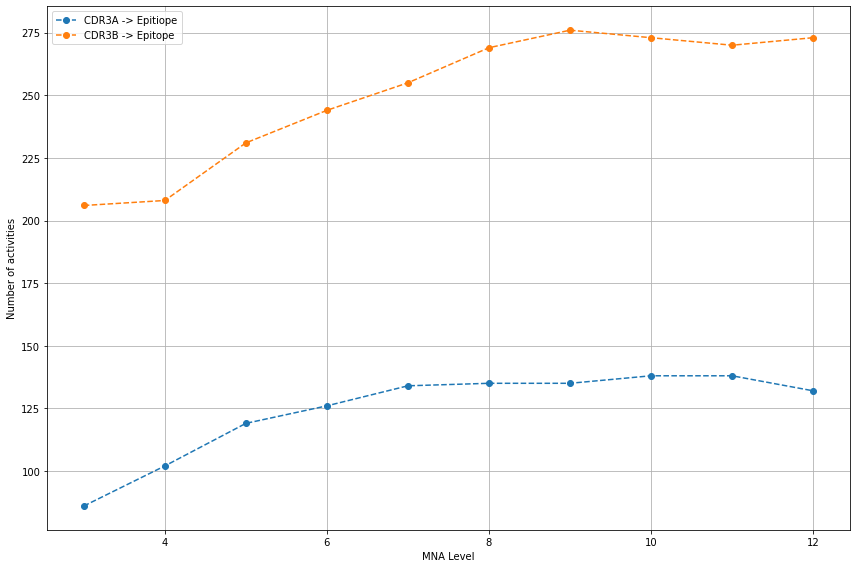

In [56]:
# We setup our figure
fig, axes = plt.subplots(1,1, figsize=(12,8))

plt.plot(cdr3a_epitope['level'], cdr3a_epitope['num_activities'],'o--', label = "CDR3A -> Epitiope")
plt.plot(cdr3b_epitope['level'], cdr3b_epitope['num_activities'],'o--', label = "CDR3B -> Epitope")
#plt.plot(epitope_mhc['level'], epitope_mhc['num_activities'],'o--', label = "Epitope -> MHC")
#plt.yticks([x for x in range(20,40,2)])
# We plot the grid
plt.grid()

# We add better labels
plt.xlabel("MNA Level")
plt.ylabel("Number of activities")

# We tidy things up
plt.tight_layout()
plt.legend()
plt.savefig("/home/stotoshka/activ_epitope.png",dpi=400,transparent=True)
# We plot our data
plt.show()


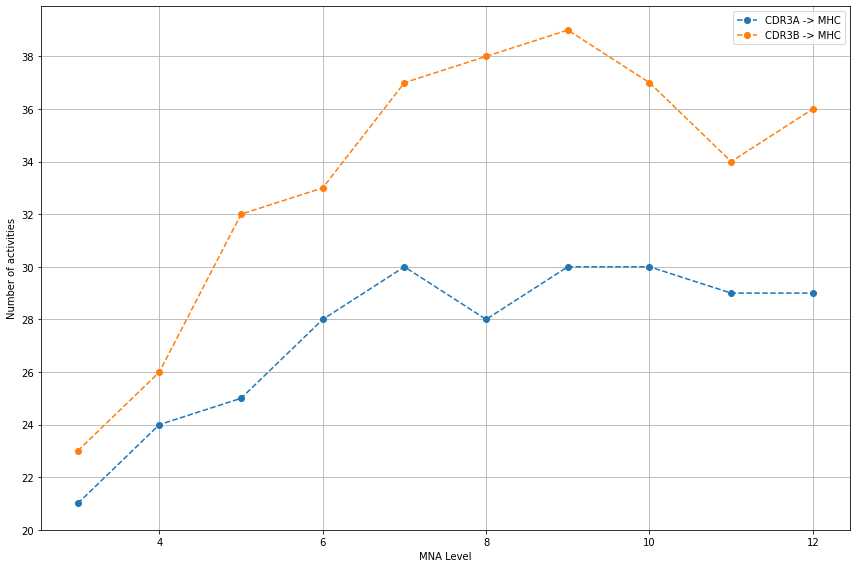

In [53]:
fig, axes = plt.subplots(1,1, figsize=(12,8))

plt.plot(cdr3a_mhc['level'], cdr3a_mhc['num_activities'],'o--', label = "CDR3A -> MHC")
plt.plot(cdr3b_mhc['level'], cdr3b_mhc['num_activities'],'o--', label = "CDR3B -> MHC")
#plt.plot(epitope_mhc['level'], epitope_mhc['num_activities'],'o--', label = "Epitope -> MHC")
plt.yticks([x for x in range(20,40,2)])
# We plot the grid
plt.grid()

# We add better labels
plt.xlabel("MNA Level")
plt.ylabel("Number of activities")

# We tidy things up
plt.tight_layout()
plt.legend()
plt.savefig("/home/stotoshka/activ_MHC.png",dpi=400,transparent=True)
# We plot our data
plt.show()


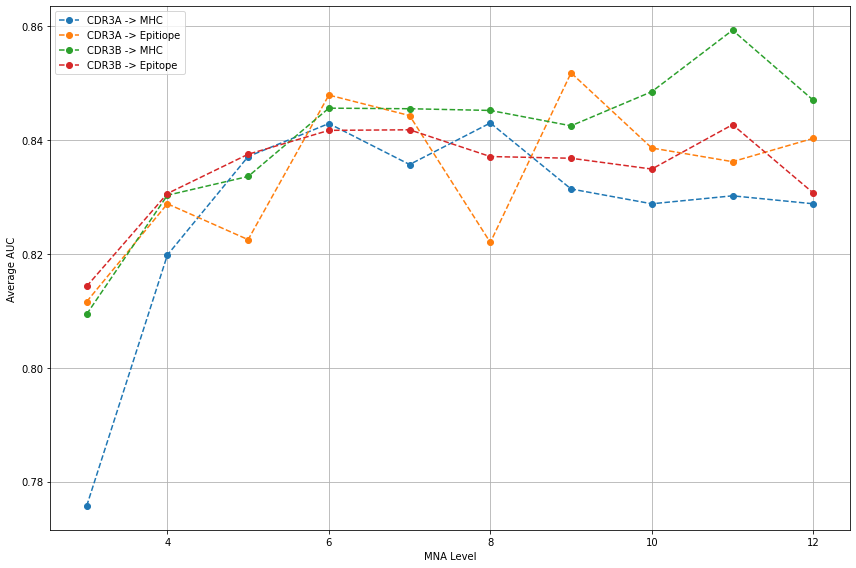

In [52]:
# We setup our figure
fig, axes = plt.subplots(1,1, figsize=(12,8))

plt.plot(cdr3a_mhc['level'], cdr3a_mhc['avIAP'],'o--', label = "CDR3A -> MHC")
plt.plot(cdr3a_epitope['level'], cdr3a_epitope['avIAP'],'o--', label = "CDR3A -> Epitiope")
plt.plot(cdr3b_mhc['level'], cdr3b_mhc['avIAP'],'o--', label = "CDR3B -> MHC")
plt.plot(cdr3b_epitope['level'], cdr3b_epitope['avIAP'],'o--', label = "CDR3B -> Epitope")
#plt.plot(epitope_mhc['level'], epitope_mhc['avIAP'],'o--', label = "Epitope -> MHC")

# We plot the grid
plt.grid()

# We add better labels
plt.xlabel("MNA Level")
plt.ylabel("Average AUC")

# We tidy things up
plt.tight_layout()
plt.legend()
plt.savefig("/home/stotoshka/iap.png",dpi=400,transparent=True)

# We plot our data
plt.show()

Level of MNA descriptors for those maximum average IAP has been reached.

In [57]:
tbl2 = pd.DataFrame(columns=tbl.columns)
uniq = tbl['model'].unique()
for u in uniq:
    tbl1 = tbl[tbl['model'] == u]
    tbl2 = tbl2.append(tbl1[tbl1['avIAP'] == tbl1['avIAP'].max()],ignore_index=True)

In [58]:
tbl2

,model,level,num_activities,avIAP
0,cdr3b_mhc,11,34,0.8593
1,cdr3b_epitope,11,270,0.8427
2,cdr3a_mhc,8,28,0.8430
3,epitope_mhc,9,44,0.9296
4,cdr3a_epitope,9,135,0.8518


In [ ]:
#all = pd.read_excel("/home/stotoshka/DataspellProjects/epitops/all_processed.xlsx")
#mhc = pd.read_excel("/home/stotoshka/DataspellProjects/epitops/cdr3_mhc.xlsx")

In [37]:
def parseValidationResult(path,spr):
    i = 0
    df = pd.DataFrame(columns=["Epitope", "Num_CDR3", "20-Fold IAP", "host_species",'db_access','epitope_id','Epitope_species','Epitope_protein'])
    flag1 = False
    flag2 = False
    for line in reversed(open(path,"r",encoding="cp1251").readlines()):
        if "End          :" in line:
            flag1 = True
            continue
        if "No	 Check	 Group" in line:
            flag1 = False
            flag2 = False
            i += 1
            if i < 20:
                continue
            else:
                break
        if flag1 and not flag2:
            flag2 = True
            continue
        if flag1 and flag2:
            cells = re.split("\t ",line.strip())
            e = cells[6].strip()
            n = int(cells[3])
            iap = float(cells[5].replace(",","."))
            print(e + " " + str(len(spr.loc[(spr.chain_i_name == e) | (spr.Epitope == e),"host_species"].index)))
            sp = spr.loc[(spr.chain_i_name == e) | (spr.Epitope == e),"host_species"].iloc[0]
            ep_sp = spr.loc[(spr.chain_i_name == e) | (spr.Epitope == e),"source_species"].iloc[0]
            ep_prot = spr.loc[(spr.chain_i_name == e) | (spr.Epitope == e),"protein_name"].iloc[0]
            db = spr.loc[(spr.chain_i_name == e) | (spr.Epitope == e),"database_access"].iloc[0]
            e_id = spr.loc[(spr.chain_i_name == e) | (spr.Epitope == e),"accession"].iloc[0]
            df = df.append({"Epitope":e,
                            "Num_CDR3":n,
                            "20-Fold IAP":iap,
                            "host_species":sp,
                            'db_access':db,
                            'epitope_id':e_id,
                            'Epitope_species':ep_sp,
                            'Epitope_protein':ep_prot} ,ignore_index=True)
    return df

In [38]:
#cdr3a_mhc = parseValidationResult("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3a_mhc_8_CRV.LOG",mhc)
#cdr3b_mhc = parseValidationResult("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3b_mhc_11_CRV.LOG",mhc)
cdr3a_epitope = parseValidationResult("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3a_epitope_9_CRV.LOG",all)
cdr3b_epitope = parseValidationResult("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3b_epitope_11_CRV.LOG",all)

YVVTWIVGA 7
YVLTWIVGA 26
YVLDHLIVV 25690
YLQPRTFLL 2181
VYALIAGATL 12
VVTGVLVYL 18
VMPFSIVYIV 22
VITAFTEGLK 56
VEALYLVAGGE 16
VEALYLVAGER 14
VEALYLVAGEE 20
VDSITEVECFLTPEM 24
VDSITEVECFLTPEA 10
VDSITEVECFLTAEM 10
VDSITEVECFLAPEM 10
VDSITEVECALTPEM 10
VDSITEVEAFLTPEM 10
VDSITEAECFLTPEM 10
VASITEVECFLTPEM 10
TVYGFCLL 518
TPRVTGGGAM 2852
TLFTIVGTV 5
TAFTIPSI 89
TAAQAAVVRFQEAAN 18
SYIPSAEKI 73
SVLENFTIFL 12
STRQALRPRADGPVG 30
SSYRRPVGI 3879
SSPPMFRV 1240
SSLENFRAYV 2670
SSCMGGMNWR 6
SQLLNAKYL 253
SPSYVYHQF 54
SLLMWITQC 108
SLAPLSPRV 29
SIYRYYGL 36
SIINFEKL 341
SGPLKAEIAQRLED 128
SGPDNGAVAV 58
RYPLTFGW 16
RVSYYGPKTSPVQ 30
RTMEVCYNT 27
RPPIFIRRL 236
RLQSLQTYV 196
RISNCVADYSVLYNS 7
RFYKTLRAEQASQ 548
QVPLRPMTYK 78
QLSPFPFDL 21
QIKVRVDMV 48
QELIRQGTDY 20
QARQMVQAMRTIGTHP 243
PFPQPELPY 27
NYNYLYRLF 96
NMINFAPNI 22
NMIHFAPNV 25
NDMLVCANI 21
NCTFEYVSQPFLMDL 16
MMPFSIVYIV 20
MEVGWYRSPFSRVVHLYRNGK 260
LVLEVDPNI 19
LSLRNPILV 914
LPRWYFYYL 68
LLYDANYFL 24
LLWNGPMAV 3460
LLLGIGILV 609
LLFGMTPCL 34
LLFG

HLVEELYLVAGEEGC 6
HGIRNASFI 1656
GQFLTPNSH 10
GPEGAQGPRGEPGTP 40
GMGPLLATV 23
GLCTLVAML 20738
GEEDGAGGHSL 11
GCQEICPAC 29
GADGVGKSAL 13
FRDYVDRFYKTLRAEQASQE 908
FLYALALLL 154
FDVMVMPNL 16
ESVAWSASACHDGIN 15
EQYKFYSV 16
EPLPQGQLTAY 200
ELAGIGLTV 30
ELAGIGILTV 3757
EIQEFCPNT 29
CINGVCWTV 335
CHIPVEPNT 12
CFVECAPVC 29
CFLLILPNC 25
ASNENMETM 1771
AEMEFCPCC 29
ADSITEVECFLTPEM 10
AARAVFLAL 6
AAGIGILTV 69
AAFKRSCLK 9
YVVTWIVGA 7
YVLTWIVGA 26
YVLDHLIVV 25690
YLQPRTFLL 2181
VYALIAGATL 12
VVTGVLVYL 18
VMPFSIVYIV 22
VITAFTEGLK 56
VEALYLVAGGE 16
VEALYLVAGER 14
VEALYLVAGEE 20
VDSITEVECFLTPEM 24
VDSITEVECFLTPEA 10
VDSITEVECFLTAEM 10
VDSITEVECFLAPEM 10
VDSITEVECALTPEM 10
VDSITEVEAFLTPEM 10
VDSITEAECFLTPEM 10
VASITEVECFLTPEM 10
TVYGFCLL 518
TPRVTGGGAM 2852
TLFTIVGTV 5
TAFTIPSI 89
TAAQAAVVRFQEAAN 18
SYIPSAEKI 73
SVLENFTIFL 12
STRQALRPRADGPVG 30
SSYRRPVGI 3879
SSPPMFRV 1240
SSLENFRAYV 2670
SSCMGGMNWR 6
SQLLNAKYL 253
SPSYVYHQF 54
SLLMWITQC 108
SLAPLSPRV 29
SIYRYYGL 36
SIINFEKL 341
SGPLKAEIAQRLED 128
SGPD

MEVGWYRSPFSRVVHLYRNGK 260
LVLEVDPNI 19
LSLRNPILV 914
LPRWYFYYL 68
LLYDANYFL 24
LLWNGPMAV 3460
LLLGIGILV 609
LLFGMTPCL 34
LLFGMPPCL 33
LLAIKVPNV 18
LLAGTLAGV 13
KVKEVCPNV 27
KTVGIYPNA 22
KRWIIMGLNK 103
KMVTVCPNT 21
KLVALGINAV 235
KLMNIQQQL 30
KLMNIQQKL 59
KLLEIAPNC 239
KIVALGINAV 13
KAVYNFATC 130
KAFSPEVIPMF 382
IMYNYPAM 26
IMIEFCPGG 16
ILTGLNYEV 121
ILNAMITKI 17
IHSLLDEGKQSLTKL 28
IAEDYFMAKAIADRG 3
HWFVTQRNFYEPQII 15
HPVGEADYFEY 146
HLVEELYLVAGEEGC 6
HGIRNASFI 1656
GQFLTPNSH 10
GPEGAQGPRGEPGTP 40
GMGPLLATV 23
GLCTLVAML 20738
GEEDGAGGHSL 11
GCQEICPAC 29
GADGVGKSAL 13
FRDYVDRFYKTLRAEQASQE 908
FLYALALLL 154
FDVMVMPNL 16
ESVAWSASACHDGIN 15
EQYKFYSV 16
EPLPQGQLTAY 200
ELAGIGLTV 30
ELAGIGILTV 3757
EIQEFCPNT 29
CINGVCWTV 335
CHIPVEPNT 12
CFVECAPVC 29
CFLLILPNC 25
ASNENMETM 1771
AEMEFCPCC 29
ADSITEVECFLTPEM 10
AARAVFLAL 6
AAGIGILTV 69
AAFKRSCLK 9
YVVTWIVGA 7
YVLTWIVGA 26
YVLDHLIVV 25690
YLQPRTFLL 2181
VYALIAGATL 12
VVTGVLVYL 18
VMPFSIVYIV 22
VITAFTEGLK 56
VEALYLVAGGE 16
VEALYLVAGER 14
VEALYLVA

SSPPMFRV 1240
SSLENFRAYV 2670
SSCMGGMNWR 6
SQLLNAKYL 253
SPSYVYHQF 54
SLLMWITQC 108
SLAPLSPRV 29
SIYRYYGL 36
SIINFEKL 341
SGPLKAEIAQRLED 128
SGPDNGAVAV 58
RYPLTFGW 16
RVSYYGPKTSPVQ 30
RTMEVCYNT 27
RPPIFIRRL 236
RLQSLQTYV 196
RISNCVADYSVLYNS 7
RFYKTLRAEQASQ 548
QVPLRPMTYK 78
QLSPFPFDL 21
QIKVRVDMV 48
QELIRQGTDY 20
QARQMVQAMRTIGTHP 243
PFPQPELPY 27
NYNYLYRLF 96
NMINFAPNI 22
NMIHFAPNV 25
NDMLVCANI 21
NCTFEYVSQPFLMDL 16
MMPFSIVYIV 20
MEVGWYRSPFSRVVHLYRNGK 260
LVLEVDPNI 19
LSLRNPILV 914
LPRWYFYYL 68
LLYDANYFL 24
LLWNGPMAV 3460
LLLGIGILV 609
LLFGMTPCL 34
LLFGMPPCL 33
LLAIKVPNV 18
LLAGTLAGV 13
KVKEVCPNV 27
KTVGIYPNA 22
KRWIIMGLNK 103
KMVTVCPNT 21
KLVALGINAV 235
KLMNIQQQL 30
KLMNIQQKL 59
KLLEIAPNC 239
KIVALGINAV 13
KAVYNFATC 130
KAFSPEVIPMF 382
IMYNYPAM 26
IMIEFCPGG 16
ILTGLNYEV 121
ILNAMITKI 17
IHSLLDEGKQSLTKL 28
IAEDYFMAKAIADRG 3
HWFVTQRNFYEPQII 15
HPVGEADYFEY 146
HLVEELYLVAGEEGC 6
HGIRNASFI 1656
GQFLTPNSH 10
GPEGAQGPRGEPGTP 40
GMGPLLATV 23
GLCTLVAML 20738
GEEDGAGGHSL 11
GCQEICPAC 29
GADGVGK

YVLDHLIVV 25690
YLQPRTFLL 2181
VYALIAGATL 12
VVTGVLVYL 18
VMPFSIVYIV 22
VITAFTEGLK 56
VEALYLVAGGE 16
VEALYLVAGER 14
VEALYLVAGEE 20
VDSITEVECFLTPEM 24
VDSITEVECFLTPEA 10
VDSITEVECFLTAEM 10
VDSITEVECFLAPEM 10
VDSITEVECALTPEM 10
VDSITEVEAFLTPEM 10
VDSITEAECFLTPEM 10
VASITEVECFLTPEM 10
TVYGFCLL 518
TPRVTGGGAM 2852
TLFTIVGTV 5
TAFTIPSI 89
TAAQAAVVRFQEAAN 18
SYIPSAEKI 73
SVLENFTIFL 12
STRQALRPRADGPVG 30
SSYRRPVGI 3879
SSPPMFRV 1240
SSLENFRAYV 2670
SSCMGGMNWR 6
SQLLNAKYL 253
SPSYVYHQF 54
SLLMWITQC 108
SLAPLSPRV 29
SIYRYYGL 36
SIINFEKL 341
SGPLKAEIAQRLED 128
SGPDNGAVAV 58
RYPLTFGW 16
RVSYYGPKTSPVQ 30
RTMEVCYNT 27
RPPIFIRRL 236
RLQSLQTYV 196
RISNCVADYSVLYNS 7
RFYKTLRAEQASQ 548
QVPLRPMTYK 78
QLSPFPFDL 21
QIKVRVDMV 48
QELIRQGTDY 20
QARQMVQAMRTIGTHP 243
PFPQPELPY 27
NYNYLYRLF 96
NMINFAPNI 22
NMIHFAPNV 25
NDMLVCANI 21
NCTFEYVSQPFLMDL 16
MMPFSIVYIV 20
MEVGWYRSPFSRVVHLYRNGK 260
LVLEVDPNI 19
LSLRNPILV 914
LPRWYFYYL 68
LLYDANYFL 24
LLWNGPMAV 3460
LLLGIGILV 609
LLFGMTPCL 34
LLFGMPPCL 33
LLAIKVPNV 18
LLA

YLQPRTFLL 2181
YLEPGPVTV 73
YLEPGPVTA 15
YAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFT 839
WEDLFCDESLSSPEPPSSSE 369
VVDKYFDCY 6
VPSPSMGRDIKVQFQ 8
VMPFSIVYI 17
VLWAHGFEL 744
VLPPLLTDEMIAQYT 668
VLHDDLLEA 50
VLENFTIFLV 15
VITAFTEGLK 56
VITAFNGELK 12
VHVSFVMAYPEMLAA 20
VELGGGPGA 18
VELGGGPG 12
VEALYLVCG 308
VEALYLVAGGE 16
VEALYLVAGER 14
VDSITEVECFLTPEM 24
VDSITEVECFLTPEA 10
VDSITEVECFLTAEM 10
VDSITEVECFLAPEM 10
VDSITEVECALTPEM 10
VDSITEVEAFLTPEM 10
VDSITEAECFLTPEM 10
VDSITAVECFLTPEM 6
VDSIAEVECFLTPEM 8
VDAITEVECFLTPEM 8
VASITEVECFLTPEM 10
TVYGFCLL 518
TVLSFCAFAV 612
TSTLQEQIGW 32
TSTLAEQMAW 3
TQGYFPDWQNY 11
TPQDLNTML 160
TPGPGVRYPL 126
TNFKYNYSVIEGGPI 15
TLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNEN 11
TLDSKTQSL 123
THLMVLCCV 17
TAFTIPSI 89
TAAQAAVVRFQEAAN 18
SYIPSAEKI 73
SYIGSINNI 128
STRQALRPRADGPVG 30
SSYRRPVGI 3879
SSPPMFRV 1240
SSLENFRAYV 2670
SSCMGGMNWR 6
SQLLNAKYL 253
SPSYVYHQF 54
SMWSFNPETNIL 198
SIINFEKL 341
SHLVEALYLVAGERG 49
SGPLKAEIAQRLED 128
SGPDNGAVAVL 43
SGPDNGAVAV 58
SEHDYQIGG

LTDEQRAAALEKAAA 14
LSLRNPILV 914
LQPFPQPELPYPQPQ 25
LPPIVAKEI 63
LLYDANYFL 24
LLWNGPMAV 3460
LLSAGIFGA 27
LLEFYLAMPFATP 3
LIIPFIHLI 27
LHMEFCSCC 11
KVPRNQDWL 10
KTVGIYPNA 22
KRWIIMGLNK 103
KRWIILGLNK 516
KRGIVEQSSTSISSL 8
KMVTVCPNT 21
KLWASPLHV 99
KLMNIQQKL 59
KINAWIKVV 7
KGYVYQGL 34
KDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQY 5
KAVYNFATC 130
KAFSPEVIPMF 382
ITDQVPFSV 21
IPSINVHHY 246
IMYNYPAM 26
IMIEFCPGG 16
ILKEPVHGV 21
IKAVYNFATCG 14
IILVAVPHV 12
IIKDYGKQM 66
IGYVYQGL 18
IASNENMETMESSTLE 5
HTTDPSFLGRY 5887
HSLGKWLGHPDKF 16
HSKKKCDEL 105
HPVGEADYFEY 146
HPKVSSEVHI 105
HLVERLYLVCGGEG 87
HLVERLYLVCGGE 14
HGIRNASFI 1656
GTSGSPIVNR 178
GTSGSPIINR 176
GPKKSTNLV 8
GPGMKARVL 17
GPEGAQGPRGEPGTP 40
GLCTLVAML 20738
GKAPRLLIHYTSALQPGI 5
GERQNATEIRASVGK 46
GAVECCPNC 14
GADGVGKSAL 13
FWIDLFETIG 14
FSKQLQQSM 17
FRDYVDRFYKTLRAEQASQE 908
FQPQNGQFI 53
FPTKDVAL 25
FPRPWLHGL 172
FNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKL 6
FMIGYTSAL 18
FLYALALLL 154
FLPFFSNVTWFHAI 311
FLKETGGL 6
FLKEQGGL 6
FLKEMGGL 6


VEALYLVAGGE 16
VEALYLVAGER 14
VDSITEVECFLTPEM 24
VDSITEVECFLTPEA 10
VDSITEVECFLTAEM 10
VDSITEVECFLAPEM 10
VDSITEVECALTPEM 10
VDSITEVEAFLTPEM 10
VDSITEAECFLTPEM 10
VDSITAVECFLTPEM 6
VDSIAEVECFLTPEM 8
VDAITEVECFLTPEM 8
VASITEVECFLTPEM 10
TVYGFCLL 518
TVLSFCAFAV 612
TSTLQEQIGW 32
TSTLAEQMAW 3
TQGYFPDWQNY 11
TPQDLNTML 160
TPGPGVRYPL 126
TNFKYNYSVIEGGPI 15
TLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNEN 11
TLDSKTQSL 123
THLMVLCCV 17
TAFTIPSI 89
TAAQAAVVRFQEAAN 18
SYIPSAEKI 73
SYIGSINNI 128
STRQALRPRADGPVG 30
SSYRRPVGI 3879
SSPPMFRV 1240
SSLENFRAYV 2670
SSCMGGMNWR 6
SQLLNAKYL 253
SPSYVYHQF 54
SMWSFNPETNIL 198
SIINFEKL 341
SHLVEALYLVAGERG 49
SGPLKAEIAQRLED 128
SGPDNGAVAVL 43
SGPDNGAVAV 58
SEHDYQIGGYTEKW 3429
RVGARKSAPL 3
RRSGPPGLQGRLQRLLQASGNHA 4
RPRGEVRFL 219
RMWDFDIFL 5
RLRPGGKKR 32
RLRPGGKKK 38
RILGAGCFV 22
RGYVYQGL 54
RGYVYKGL 10
RGYVYEGL 41
RGYVYDGL 9
RFYKTLRAEQASQ 548
RDAMDRIF 25
RCMLQCPSV 15
RALEYKNL 373
QYDPVAALF 106
QVPSASMGRDIKVQF 8
QLMCQPILLL 976
QIKVRVKMV 63
QIKVRVDMV 48
QELIRQGTDYKHW

KeyboardInterrupt: 

In [ ]:
#cdr3a_mhc.groupby(['Epitope'], as_index=False).agg(
 #   {'20-Fold IAP':['mean','var'],'Num_CDR3':'first', 'host_species':'first'}).to_excel("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3a_mhc_8_res.xlsx")
#cdr3b_mhc.groupby(['Epitope'], as_index=False).agg(
  #  {'20-Fold IAP':['mean','var'],'Num_CDR3':'first', 'host_species':'first'}).to_excel("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3b_mhc_11_res.xlsx")
cdr3a_epitope.groupby(['Epitope'], as_index=False).agg(
    {'20-Fold IAP':['mean','var'],'Num_CDR3':'first', 'host_species':'first','db_access':'first', 'epitope_id':'first','Epitope_species':'first','Epitope_protein':'first'}).to_excel("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3a_epitope_9_res.xlsx")
cdr3b_epitope.groupby(['Epitope'], as_index=False).agg(
    {'20-Fold IAP':['mean','var'],'Num_CDR3':'first', 'host_species':'first','db_access':'first', 'epitope_id':'first','Epitope_species':'first','Epitope_protein':'first'}).to_excel("/home/stotoshka/DataspellProjects/epitops/sarm/cdr3b_epitope_11_res.xlsx")

In [ ]:
all.loc[all['Epitope'] == 'VEALYLVAGGE',:]

In [ ]:
len(all['linear_peptide_seq'].unique())

In [ ]:
len(all.loc[all['chain_type']=='alpha','Epitope'].unique())

In [ ]:
len(all.loc[all['chain_type']=='beta','Epitope'].unique())